In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

snaps = pd.read_csv("data/snapshots.csv", parse_dates=["resolved_at"])
HORIZONS = sorted(snaps["horizon_days"].unique())

print(snaps.groupby("horizon_days").agg(
    n=("outcome", "size"),
    markets=("market_id", "nunique"),
    events=("event_id", "nunique"),
    yes_rate=("outcome", "mean"),
))

                n  markets  events  yes_rate
horizon_days                                
1             375      375     233  0.458667
3             265      265     163  0.422642
7             213      213     128  0.389671
14            183      183     105  0.349727
30            140      140      80  0.335714


In [2]:
def wilson_ci(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - half, center + half

def calibration_table(df, n_bins=10):
    df = df.copy()
    df["bin"] = pd.qcut(df["price"], q=n_bins, duplicates="drop")
    t = df.groupby("bin", observed=True).agg(
        n=("outcome", "size"),
        wins=("outcome", "sum"),
        avg_price=("price", "mean"),
    )
    t["win_rate"] = t["wins"] / t["n"]
    t["ci_lo"], t["ci_hi"] = wilson_ci(t["wins"], t["n"])
    t["gap"] = t["win_rate"] - t["avg_price"] 
    return t

calibration_table(snaps[snaps["horizon_days"] == 7])

,n,wins,avg_price,win_rate,ci_lo,ci_hi,gap
bin,,,,,,,
"(-0.0005, 0.008]",23,0,0.005000,0.000000,-1.387779e-17,0.143121,-0.005000
"(0.008, 0.015]",21,0,0.011905,0.000000,0.000000e+00,0.154644,-0.011905
"(0.015, 0.029]",20,0,0.021050,0.000000,-1.387779e-17,0.161130,-0.021050
"(0.029, 0.082]",21,2,0.045810,0.095238,2.651821e-02,0.289146,0.049429
"(0.082, 0.23]",22,3,0.145682,0.136364,4.748917e-02,0.333354,-0.009318
"(0.23, 0.45]",22,10,0.335455,0.454545,2.692001e-01,0.653405,0.119091
"(0.45, 0.522]",20,10,0.495250,0.500000,2.992949e-01,0.700705,0.004750
"(0.522, 0.793]",21,17,0.662619,0.809524,5.999901e-01,0.923326,0.146905
"(0.793, 0.929]",21,19,0.857333,0.904762,7.108542e-01,0.973482,0.047429


ValueError: 'yerr' must not contain negative values

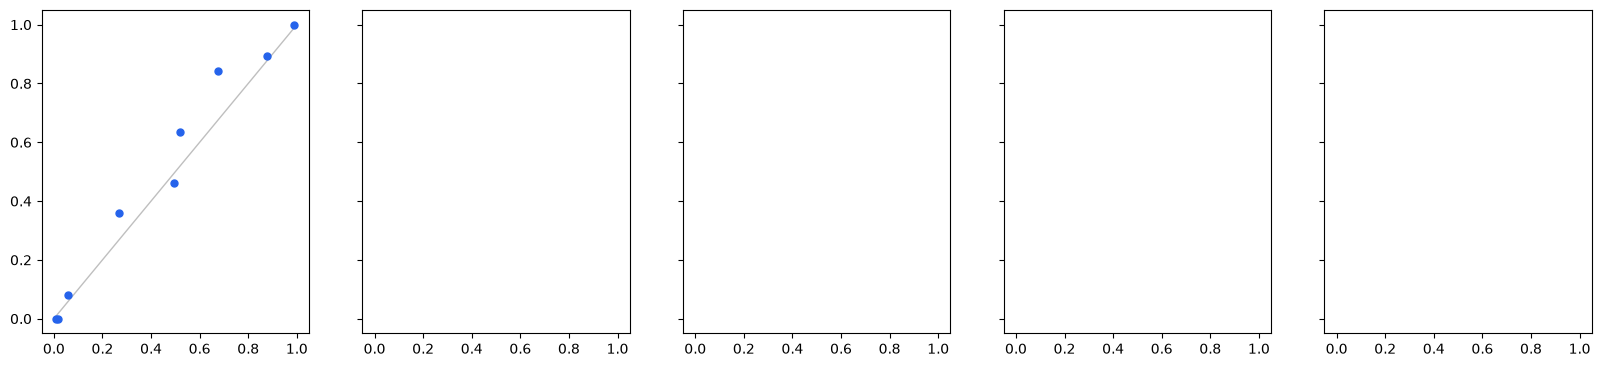

In [3]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(4 * len(HORIZONS), 4.2),
                         sharex=True, sharey=True)

for ax, h in zip(axes, HORIZONS):
    t = calibration_table(snaps[snaps["horizon_days"] == h])
    ax.plot([0, 1], [0, 1], color="0.75", lw=1, zorder=0)
    ax.errorbar(t["avg_price"], t["win_rate"],
                yerr=[t["win_rate"] - t["ci_lo"], t["ci_hi"] - t["win_rate"]],
                fmt="o", ms=5, lw=1.5, capsize=0, color="#2563eb")
    ax.set_title(f"T − {h} days  (n={int(t['n'].sum())})")
    ax.set_xlabel("market price")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("actual YES win rate")
fig.suptitle("Reliability diagram：price vs actual win rate", y=1.02)
plt.tight_layout();